# Assignment 1: Text Classification
Student Name: Tuong Vy Vu (SID: 48706094)

## 0.General settings

In [1]:
%pip install -U datasets transformers accelerate

Note: you may need to restart the kernel to use updated packages.


In [2]:
SEED = 42

## 1. Data Collection

Rubric [Maximum 8 marks]:
- Reusing a publicly available dataset [4 marks] or Collecting a proprietary dataset [6 marks]
- Data splitting [2 marks]

This section describes how the dataset was constructed for human vs machine-generated text classification. Compared with the baseline (English-only HC3), the advanced dataset is designed to be multilingual and to include multiple AI generators, while keeping the task definition unchanged (label 0 = human, label 1 = machine-generated).

### 1.1 Data sources and motivation

The final dataset was constructed as a multilingual question-answer corpus for human-versus-machine text classification. I used a hybrid collection strategy. For English and Chinese, I reused publicly available human-written question-answer pairs from HC3, since this corpus already aligns well with the task of distinguishing human answers from AI-generated ones. For Vietnamese, I collected my own human-written QA pairs because HC3 does not provide an equivalent Vietnamese split. After obtaining the human side of the corpus, I used `data_crawler.ipynb` to build the Vietnamese human dataset and `dataset_builder.ipynb` to generate the AI-written side of the custom multilingual dataset.

For the Vietnamese data, I crawled public Reddit communities that contain informal Vietnamese discussion and question-answer interactions, specifically `r/vozforums`, `r/TroChuyenLinhTinh`, `r/VietNamNation`, and `r/VietTalk`. The crawler accessed Reddit JSON endpoints from `old.reddit.com`, retrieved top posts from each community, and then selected posts that looked like genuine questions. For each accepted post, the post title and body were combined into a single question field, and the highest-scored valid top-level comment was selected as the human answer. Additional filters were applied to improve quality: low-score posts were discarded, posts without comments were skipped, deleted or removed comments were excluded, duplicate questions were removed, and very short answers were filtered out. This process produced HC3-style Vietnamese records with a `question`, `human_answers`, `source`, and `post_id`.

### 1.2 Why QA pairs were chosen

I chose a QA-pair format because it is a strong setting for human-versus-machine text classification. In online forums, questions often trigger natural, spontaneous, and context-dependent answers. Compared with isolated sentences or highly edited documents, question-answer interactions tend to preserve more human writing signals such as hesitation, stance, emotion, slang, subjectivity, explanation style, and pragmatic context. These characteristics are useful because the classification task is not only about grammar quality, but also about identifying the linguistic and discourse-level traces that distinguish genuine human responses from generated ones.

A second reason for using forum QA pairs is that community feedback offers a weak but useful quality signal. Posts and comments with more upvotes are more likely to be relevant, readable, and accepted by other users in the discussion. This does not guarantee that a text is human-written, but it increases the likelihood that the selected responses are authentic community contributions rather than noise, spam, or low-quality content. For this reason, the Vietnamese crawler uses engagement-based filtering and selects the best-scored valid comment as the answer, whose data-collection strategy I believe also the same for HC3 dataset. This helps the dataset contain responses that other users considered meaningful, which makes the final corpus more suitable for training and evaluation.

### 1.3 Why this collection strategy is worthwhile

This collection strategy is valuable for three reasons. First, it extends the task beyond English by introducing Vietnamese, which makes the classification problem more realistic and more challenging. Second, it combines reused public data with a custom-collected language split, allowing the dataset to remain comparable to HC3 while also contributing a new multilingual component. Third, it uses socially grounded answers rather than artificially written examples, which makes the resulting classification task closer to real-world moderation, provenance analysis, and AI-content detection settings.

This dataset can also contribute to future research. Because it includes multiple languages and both human and machine answers for the same general QA format, it can support comparative studies on cross-lingual robustness, domain transfer, stylistic differences between languages, and generator-specific artifacts. In future work, the dataset could be expanded with more Vietnamese communities, more balanced topical coverage, or additional AI generators. Or we can apply the same strategy to collect data from other languages. It may also be useful for studying whether detectors trained on one language or source generalize to another, which is important for building reliable multilingual AI-text detection systems.

### 1.4 Building the AI-generated portion

After preparing the human-written prompts, I used dataset_builder.ipynb to construct the full custom dataset. This notebook builds three balanced JSONL files: `en_qa.jsonl`, `zh_qa.jsonl`, and `vi_qa.jsonl`, each containing 300 question-answer pairs. On the human side, the English prompts were sampled from the `reddit_eli5` subset of HC3, the Chinese prompts were sampled from the `open_qa` subset of HC3-Chinese, and the Vietnamese prompts were loaded from the crawled Vietnamese JSONL file. On the machine side, answers were generated using `Qwen2.5-1.5B-Instruct` with a language-specific prompt template of the form: `Answer this question in {language} in 100-300 words: "{question}"`. This keeps the generation procedure consistent across English, Chinese, and Vietnamese.

The reason for generating the AI side in this controlled way is to ensure that each language has the same general structure: a prompt, a human answer, and a machine-generated answer. That consistency makes downstream comparison more reliable, because the classification model can focus on differences in writing style and generation behavior rather than differences in task format.

### 1.5 Data loading

The final dataset includes three languages: EN, ZH, VI. For the machine-generated class, we include only one generator: the open-source model **Qwen2.5-1.5B-Instruct**, which generated answers for EN, ZH, and VI prompts. This enables multilingual coverage while keeping the classification task consistent.

The cells below load the raw data: HC3-EN and HC3-ZH from Hugging Face, and the Vietnamese QA pairs from the crawled JSONL file or the built `vi_qa.jsonl` produced by `dataset_builder.ipynb`.

#### 1.5.1 Imports, config, and stable_prompt_id

In [3]:
import random
import hashlib
import json
from pathlib import Path
from datasets import load_dataset, Dataset, DatasetDict
from collections import Counter

random.seed(SEED)
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.7, 0.15, 0.15

# Create a stable ID for a prompt/question (used for leakage-safe splitting)
def stable_prompt_id(lang: str, question: str) -> str:
    s = f"{lang}||{question}".strip().encode("utf-8")
    return hashlib.sha1(s).hexdigest()[:16]

#### 1.5.2 Load built multilingual data (en/zh/vi)

In [4]:
def load_qa_jsonl(path: str, lang: str):
    """Load QA JSONL from en_qa.jsonl, zh_qa.jsonl, or vi_qa.jsonl.
    Schema: {question, human_answers, ai_answers, index, source}
    """
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            q = (obj.get("question") or "").strip()
            human = obj.get("human_answers") or []
            ai = obj.get("ai_answers") or []
            if not q or not human or not ai:
                continue
            h = human[0] if isinstance(human[0], str) else str(human[0])
            a = ai[0] if isinstance(ai[0], str) else str(ai[0])
            # if len(h) < 20 or len(a) < 20:
            #     continue
            rows.append({
                "question": q,
                "human_answers": [h],
                "ai_answers": [a],
                "index": obj.get("index") or obj.get("post_id"),
                "source": obj.get("source", f"{lang}_built"),
                "lang": lang,
            })
    return rows

# Load all three languages (built by dataset_builder.ipynb)
BASE = Path(".") 
en_rows = load_qa_jsonl(BASE / "en_qa.jsonl", "en")
zh_rows = load_qa_jsonl(BASE / "zh_qa.jsonl", "zh")
vi_rows = load_qa_jsonl(BASE / "vi_qa.jsonl", "vi")

print(f"EN: {len(en_rows)} QA pairs")
print(f"ZH: {len(zh_rows)} QA pairs")
print(f"VI: {len(vi_rows)} QA pairs")
print(f"Total prompts: {len(en_rows) + len(zh_rows) + len(vi_rows)}")

EN: 300 QA pairs
ZH: 300 QA pairs
VI: 300 QA pairs
Total prompts: 900


### 1.6 Labelling, balancing, and leakage-safe splitting

Each sample is labelled as 0 for human-written text and 1 for machine-generated text. To avoid introducing language imbalance, I keep the dataset balanced across English, Chinese, and Vietnamese. Since each language contains 300 QA pairs, I split each language separately at the prompt level using a 70/15/15 ratio, then merge the resulting splits. This ensures that the train, validation, and test sets contain equal portions of EN, ZH, and VI data.

Splitting is performed at the prompt/question level before flattening into individual text samples. All texts derived from the same prompt_id are kept in the same split. This prevents leakage, because the model never sees the same prompt in both training and evaluation.

In [5]:
def split_by_ratio(rows, seed=SEED, train_ratio=0.7, val_ratio=0.15):
    rows = rows.copy()
    random.Random(seed).shuffle(rows)
    n = len(rows)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_rows = rows[:n_train]
    val_rows = rows[n_train:n_train + n_val]
    test_rows = rows[n_train + n_val:]
    return train_rows, val_rows, test_rows

en_train, en_val, en_test = split_by_ratio(en_rows, seed=SEED)
zh_train, zh_val, zh_test = split_by_ratio(zh_rows, seed=SEED)
vi_train, vi_val, vi_test = split_by_ratio(vi_rows, seed=SEED)

raw_train = en_train + zh_train + vi_train
raw_val = en_val + zh_val + vi_val
raw_test = en_test + zh_test + vi_test

random.Random(SEED).shuffle(raw_train)
random.Random(SEED).shuffle(raw_val)
random.Random(SEED).shuffle(raw_test)

print("Prompt counts by split: en/zh/vi")
print("train:", len(en_train), len(zh_train), len(vi_train))
print("val:", len(en_val), len(zh_val), len(vi_val))
print("test:", len(en_test), len(zh_test), len(vi_test))

Prompt counts by split: en/zh/vi
train: 210 210 210
val: 45 45 45
test: 45 45 45


### 1.7 Final dataset format

After preprocessing, all experiments use a unified schema:
- **text:** the answer text used as model input
- **label:** 0 (human) / 1 (machine)
- **lang:** en/zh/vi
- **gen:** human or oss
    - human: the answer is human-written
    - oss: the answer is machine-generated by the open-source model (now is Qwen2.5-1.5B-Instruct)
- **prompt_id:** identifier used for leakage-safe splitting


**Note:** 
Field `gen` supports multiple generators. In the future, if we want to include more generators "gpt", "claude", "gemini", we can add them to this field.

In [6]:
def create_labeled_examples(split_data):
    """Flatten QA pairs: one row per answer, label 0=human, 1=machine.
    Uses ai_answers (Qwen) as the machine generator.
    """
    texts, labels, langs, gens, prompt_ids = [], [], [], [], []
    for row in split_data:
        lang = row.get("lang", "en")
        q = row.get("question", "")
        pid = stable_prompt_id(lang, q)
        human = row.get("human_answers") or []
        ai = row.get("ai_answers") or []
        if not human or not ai:
            continue
        h = human[0] if isinstance(human[0], str) else str(human[0])
        a = ai[0] if isinstance(ai[0], str) else str(ai[0])
        texts.extend([h, a])
        labels.extend([0, 1])
        langs.extend([lang, lang])
        gens.extend(["human", "oss"])
        prompt_ids.extend([pid, pid])
    return Dataset.from_dict({
        "text": texts,
        "label": labels,
        "lang": langs,
        "gen": gens,
        "prompt_id": prompt_ids,
    })

train_data = create_labeled_examples(raw_train)
val_data = create_labeled_examples(raw_val)
test_data = create_labeled_examples(raw_test)

dataset = DatasetDict({
    "train": train_data,
    "validation": val_data,
    "test": test_data,
})

print("Labeled dataset for classification (0=human, 1=machine-generated):")
print(dataset)
print("\nLabel counts - train:", Counter(train_data["label"]),
      "| val:", Counter(val_data["label"]),
      "| test:", Counter(test_data["label"]))
print("\nExample human (label=0):", train_data[0]["text"][:150], "...")
print("\nExample machine (label=1):", train_data[1]["text"][:150], "...")

Labeled dataset for classification (0=human, 1=machine-generated):
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'lang', 'gen', 'prompt_id'],
        num_rows: 1260
    })
    validation: Dataset({
        features: ['text', 'label', 'lang', 'gen', 'prompt_id'],
        num_rows: 270
    })
    test: Dataset({
        features: ['text', 'label', 'lang', 'gen', 'prompt_id'],
        num_rows: 270
    })
})

Label counts - train: Counter({0: 630, 1: 630}) | val: Counter({0: 135, 1: 135}) | test: Counter({0: 135, 1: 135})

Example human (label=0): Buồn cười là đoạn thằng tàu thì chờ vn có biến lớn để chúng nó ngó theo, còn thực tế ở vn thì chờ tq có biến để vn được hưởng lợi. Má 2 thằng chờ qua  ...

Example machine (label=1): Tôi hiểu rằng bạn đang hỏi về Phe dân chủ Trung Quốc và những phản ứng của họ khi Tô Thái Thú đăng cai chức Chủ tịch nước. Dưới đây là một đoạn trả lờ ...


## 2. Data Analysis
Rubric [Maximum 8 marks]:
- Feature Extraction [2 marks]: Either one-hot and TF-IDF approaches are acceptable for full marks here; however using both will provide you with more experiments to discuss in the next two questions
- Statistical classifier [2 marks]: Correctly implementing logistic regression (or other more advanced statistical classifiers) with reasonable performance will be worth full marks here
- Comparison [2 marks]: Comparing different settings of your experiments, e.g., varying features, classifiers or datasets. 1 marks for each comparison experiment.
- Analysis and report [2 marks]: Full marks can be earned by analysing your classifier's weights to identify the key factors or features

In Section 2, we build an interpretable pipeline to distinguish **Human** vs **Machine** text.
- 2.0: Quick descriptive signals to motivate the task (length, diversity, punctuation, etc.).
- 2.1: Extract n‑gram features using one-hot and TF‑IDF (with the same preprocessing).
- 2.2: Train statistical classifiers and run two controlled experiments:
  - Experiment 1: feature comparison (one-hot vs TF‑IDF) with the same classifier.
  - Experiment 2: classifier comparison (Logistic Regression vs MultinomialNB) with the same features.
- 2.3: Interpret the Logistic Regression model by analysing its most influential features.

### 2.0 Intuitive corpus-level signals that may separate Human vs Machine text

Before feature extraction, I inspect several simple descriptive signals from the training split to identify broad differences between the Human and Machine classes. These statistics are used as **coarse corpus-level signals** only; they are not intended to be universally comparable linguistic measures across all languages in the dataset.

We compare:
- text length (`n_words`),
- lexical diversity (unique-to-total token ratio),
- punctuation density,
- uppercase token ratio,
- average word length.

Because the corpus includes English, Chinese, and Vietnamese, some features are more language-dependent than others. In particular, uppercase usage is more informative for alphabetic languages such as English than for Chinese, while token-based measures such as `n_words`, lexical diversity, and average word length depend on script and tokenization. Therefore, these values should be interpreted as rough summaries of the multilingual corpus rather than direct comparisons across languages.

In [7]:
import re
import numpy as np
import pandas as pd

# Build a small analysis dataframe from the labeled dataset
df_analysis = pd.DataFrame({
    "text": dataset["train"]["text"],
    "label": dataset["train"]["label"]
})
df_analysis["class"] = df_analysis["label"].map({0: "Human", 1: "Machine"})

def basic_text_stats(text):
    if not isinstance(text, str):
        return 0, 0.0, 0.0, 0.0, 0.0

    tokens = re.findall(r"\b\w+\b", text.lower())
    n_tokens = len(tokens)
    n_unique = len(set(tokens))
    lexical_div = (n_unique / n_tokens) if n_tokens > 0 else 0.0

    punct_count = len(re.findall(r"[^\w\s]", text))
    punct_density = punct_count / max(len(text), 1)

    upper_tokens = re.findall(r"\b[A-Z]{2,}\b", text)
    uppercase_ratio = len(upper_tokens) / max(n_tokens, 1)

    avg_word_len = (sum(len(t) for t in tokens) / n_tokens) if n_tokens > 0 else 0.0
    return n_tokens, lexical_div, punct_density, uppercase_ratio, avg_word_len

# Compute descriptive statistics
stats = df_analysis["text"].apply(basic_text_stats)
df_analysis[["n_words", "lexical_div", "punct_density", "uppercase_ratio", "avg_word_len"]] = pd.DataFrame(
    stats.tolist(), index=df_analysis.index
)

summary = (
    df_analysis.groupby("class")[["n_words", "lexical_div", "punct_density", "uppercase_ratio", "avg_word_len"]]
    .mean()
    .round(4)
)

print("Average descriptive statistics by class:")
display(summary)

print("\nClass counts in train split:")
display(df_analysis["class"].value_counts())

Average descriptive statistics by class:


,n_words,lexical_div,punct_density,uppercase_ratio,avg_word_len
class,,,,,
Human,88.2381,0.8207,0.0538,0.0050,5.6060
Machine,148.1381,0.7847,0.0487,0.0027,6.2761



Class counts in train split:


class
Human      630
Machine    630
Name: count, dtype: int64

**Interpretation**

From the train split:

- **Text length (n_words):** Machine-generated texts tend to be longer (~148 vs ~88 words), suggesting a more verbose, explanatory style.
- **Lexical diversity:** Human texts show slightly higher unique/total word ratio (~0.82 vs ~0.78), indicating more varied vocabulary; machine texts reuse more words.
- **Punctuation density:** Human texts have higher punctuation density (0.0538 vs 0.0487), suggesting more casual punctuation use.
- **Uppercase ratio:** Human texts use more uppercase tokens (e.g. acronyms, emphasis) (0.0050 vs 0.0027), although uppercase is not equally meaningful across English, Chinese, and Vietnamese.
- **Average word length:** Machine-generated words tend to be longer on average (6.2761 vs 5.6060).
- **Class balance:** Train split is balanced (630 Human, 630 Machine).

These patterns suggest that human vs machine texts differ in style and vocabulary, which supports using n-gram features and statistical classifiers in the following sections. Because the corpus mixes English, Chinese, and Vietnamese, some statistics (e.g. uppercase ratio) are more meaningful for alphabetic languages and should be interpreted as rough multilingual heuristics.

### 2.1 Feature Extraction (2 marks)

The initial vectorization below illustrates the noise issue. 

Except for Section 2.1, all experiments in Section 2.2 use the number-cleaned one-hot/TF‑IDF features for fair comparison and improved interpretability.

#### 2.1.1 One-hot encoding with unigrams and bigrams

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

# Fit on train texts only; then transform all splits
corpus = dataset["train"]["text"]
onehot = CountVectorizer(
    binary=True, 
    min_df=2,
    ngram_range=(1, 2),
    )
X_train_onehot = onehot.fit_transform(corpus)

# Print the features
onehot_features = onehot.get_feature_names_out()
n_onehot_features=len(onehot_features)
print("Number of features:", n_onehot_features)
print("First 50 features:", onehot_features[:50])
print("Last 50 features:", onehot_features[n_onehot_features-50:n_onehot_features])

Number of features: 19756
First 50 features: ['000' '10' '10 15' '10 20' '10 năm' '100' '1000' '10tr' '11' '12'
 '12 hours' '13' '14' '15' '15 000' '15 years' '16' '16th' '18' '19'
 '1945' '1950' '1950 and' '1970s' '1986' '1986 and' '19th' '19th century'
 '20' '20 30' '20 năm' '200' '2000' '2015年' '2022' '2023' '2024' '2025'
 '20th' '20th century' '21' '21259' '22' '22267' '24' '24 fps' '24 hours'
 '25' '2500' '27']
Last 50 features: ['然后' '然后选择' '然而' '然而 在现实生活中' '然而 随着时间的推移' '物理内存' '物理内存 也称为ram' '生活习惯'
 '病情分析' '的情况' '的意思' '的问题' '相比之下' '第一' '简称' '简而言之' '经济' '综上所述' '而不是'
 '肾上腺素决定出不出手' '至于' '补充' '记住' '设置' '请告诉我' '请告诉我 我会尽力为您提供帮助' '请注意' '请记住'
 '请随时告诉我' '请随时告诉我 我会尽力为您提供支持和解答' '请随时提问' '谢谢' '谢邀' '近年来' '还有' '这个问题'
 '这个问题的答案因人而异' '这样' '这种情况下' '通常情况下' '那么' '随着时间的推移' '需要明确的是' '需要注意的是'
 '风险管理' '首先' '首先 我们需要明确的是' '首先 需要明确的是' '首先需要明确的是' '马自达mx']


**Comment:**  
There are 2 issues happening here:

1. CountVectorizer's tokenizer treats punctuation as separator:

It seems like CountVectorizer's tokenizer treats punctuation as separator. For example:  
- '100,000 kilometers' after tokenizing becomes ['100', '000', 'kilometers']
- '20.5' after tokenizing becomes ['20', '5']  

This behavior is not desirable because it leads to noisy features. For example, '000' '10 15' '15 000'.
These are usually not very interpretable and may not help much with explaining the difference between human and AI Generated answers.

==> To address this, we can pre-clean numbers before vectorization.

2. Incorrect Chinese tokenization

Looking at the last 50 features above, we notice that Chinese features like `我无法回答这个问题`, `请随时告诉我 我会尽力为您提供支持和解答`, and `首先需要明确的是` are entire clauses treated as single tokens. This happens because sklearn's default `token_pattern` (`\b\w\w+\b`) matches any sequence of 2+ Unicode word characters bounded by word boundaries. Since Chinese text has no spaces between characters, every run of characters between punctuation marks becomes one giant token.

For example, the sentence fragment `对不起，我无法回答这个问题。` is split on `，` and `。`, producing:
- `对不起` → one "unigram" (actually 3 Chinese words merged)
- `我无法回答这个问题` → one "unigram" (actually a 5-word clause: 我/无法/回答/这个/问题)

As a result, bigrams of such tokens become extremely long and specific (e.g. `请随时告诉我 我会尽力为您提供支持和解答`), which hurts interpretability and generalisation.

==> To address this, we apply Chinese word segmentation using `jieba` before vectorization. This inserts spaces between Chinese words so that the default tokenizer can split them properly.

##### One-hot encoding with number cleaning + Chinese word segmentation

In [9]:
%pip install jieba -q

Note: you may need to restart the kernel to use updated packages.


In [10]:
import jieba
import re

def segment_chinese(text):
    """Segment Chinese character sequences into words using jieba."""
    if not isinstance(text, str):
        return text
    def _seg(match):
        return ' '.join(jieba.cut(match.group()))
    return re.sub(r'[\u4e00-\u9fff]+', _seg, text)

def replace_numbers_with_placeholder(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r'\b\d[\d,.]*\b', ' NUM ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_corpus(texts):
    """Apply number cleaning + Chinese word segmentation."""
    return [segment_chinese(replace_numbers_with_placeholder(t)) for t in texts]

# Clean all splits
train_texts_seg = clean_corpus(dataset["train"]["text"])
val_texts_seg   = clean_corpus(dataset["validation"]["text"])
test_texts_seg  = clean_corpus(dataset["test"]["text"])

# Vectorize using cleaned text
onehot = CountVectorizer(binary=True, min_df=2, ngram_range=(1, 2))
X_train_onehot = onehot.fit_transform(train_texts_seg)

# Transform the validation and test splits
X_val_onehot   = onehot.transform(val_texts_seg)
X_test_onehot  = onehot.transform(test_texts_seg)

# Print the features
onehot_features = onehot.get_feature_names_out()
n_onehot_features = len(onehot_features)
print("Number of features:", n_onehot_features)
print("First 50 features:", onehot_features[:50])
print("Last 50 features:", onehot_features[n_onehot_features-50:n_onehot_features])

Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
Loading model cost 0.901 seconds.
Prefix dict has been built successfully.


Number of features: 24681
First 50 features: ['10tr' '16th' '1970s' '19th' '19th century' '2015年' '20th' '20th century'
 '24小时' '3d' '3rd' '50k' 'abdomen' 'abilities' 'ability' 'ability to'
 'able' 'able to' 'about' 'about all' 'about an' 'about being'
 'about different' 'about how' 'about is' 'about it' 'about its'
 'about num' 'about one' 'about the' 'about their' 'about these'
 'about things' 'about what' 'about whether' 'about why' 'above'
 'above the' 'above your' 'absence' 'absence of' 'absorb' 'absorbed'
 'absorbed into' 'absorbing' 'absorption' 'abstract' 'abundant' 'ac'
 'academic']
Last 50 features: ['饮食' '饮食 有助于' '饮食 调整' '饮食习惯' '饱和度' '饱和度 num' '首先' '首先 了解' '首先 学习' '首先 我们'
 '首先 根据' '首先 考虑' '首先 通过' '首先 需要' '香水' '马自达mx' '驾驶' '驾驶 乐趣' '驾驶 体验' '驾驶者'
 '验证' '骗子' '骨折' '高低' '高分' '高品质' '高度' '高效' '高校' '高科技' '高科技 产业' '高端' '高等学府'
 '高级' '高质量' '高质量 内容' '高速' '魂石' '魅力' '鱼类' '鲜味' '鸡眼' '麻烦' '黄昏' '黑影' '黑色'
 '黛莱美' '鼓励' '鼓励 支持' '齐全']


**Comment:**  
1. Pre-cleaning numbers:

- Although pre-cleaning numbers slightly increases the feature count, this is not a problem. Without cleaning, the vectorizer splits values like `100,000` into noisy fragments such as `100` and `000`, which are hard to interpret. After replacing numbers with `NUM`, many different numeric forms are merged into a shared token, which can also create more frequent bigrams such as `about num` or `num years`; this is why the final number of retained features can be slightly larger.  

- Even so, the pre-cleaned approach is better because the resulting features are more meaningful, less noisy, and easier to interpret. In contrast, the non-cleaned approach keeps many number-specific fragments that do not generalize well and add little explanatory value.

2. Chinese tokenization:
The same Chinese tokenization issue observed in Section 2.1.1 also affects TF-IDF features: clause-level Chinese tokens instead of word-level tokens. We apply the same jieba segmentation (already computed above as `train_texts_seg`, `val_texts_seg`, `test_texts_seg`) to produce word-level Chinese features for TF-IDF.

#### 2.1.2 TF-IDF with unigrams and bigrams

##### TF-IDF with number cleaning + Chinese word segmentation

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize using cleaned text
tfidf = TfidfVectorizer(
    min_df=2,
    ngram_range=(1, 2),
    sublinear_tf= True,
)
X_train_tfidf = tfidf.fit_transform(train_texts_seg)

# Transform the validation and test splits
X_val_tfidf   = tfidf.transform(val_texts_seg)
X_test_tfidf  = tfidf.transform(test_texts_seg)

# Print the features
tfidf_features = tfidf.get_feature_names_out()
n_tfidf_features = len(tfidf_features)
print("Number of features:", n_tfidf_features)
print("First 50 features:", tfidf_features[:50])
print("Last 50 features:", tfidf_features[n_tfidf_features-50:n_tfidf_features])



Number of features: 24681
First 50 features: ['10tr' '16th' '1970s' '19th' '19th century' '2015年' '20th' '20th century'
 '24小时' '3d' '3rd' '50k' 'abdomen' 'abilities' 'ability' 'ability to'
 'able' 'able to' 'about' 'about all' 'about an' 'about being'
 'about different' 'about how' 'about is' 'about it' 'about its'
 'about num' 'about one' 'about the' 'about their' 'about these'
 'about things' 'about what' 'about whether' 'about why' 'above'
 'above the' 'above your' 'absence' 'absence of' 'absorb' 'absorbed'
 'absorbed into' 'absorbing' 'absorption' 'abstract' 'abundant' 'ac'
 'academic']
Last 50 features: ['饮食' '饮食 有助于' '饮食 调整' '饮食习惯' '饱和度' '饱和度 num' '首先' '首先 了解' '首先 学习' '首先 我们'
 '首先 根据' '首先 考虑' '首先 通过' '首先 需要' '香水' '马自达mx' '驾驶' '驾驶 乐趣' '驾驶 体验' '驾驶者'
 '验证' '骗子' '骨折' '高低' '高分' '高品质' '高度' '高效' '高校' '高科技' '高科技 产业' '高端' '高等学府'
 '高级' '高质量' '高质量 内容' '高速' '魂石' '魅力' '鱼类' '鲜味' '鸡眼' '麻烦' '黄昏' '黑影' '黑色'
 '黛莱美' '鼓励' '鼓励 支持' '齐全']


**Comment:**  
The same phenomenon applies to TF-IDF: pre-cleaning numbers can slightly increase the feature count compared to the non-cleaned setup. Without cleaning, values like `100,000` are split into fragments such as `100` and `000`, which often appear too rarely and are filtered out by `min_df=2`. After replacing numbers with `NUM`, many variants are merged into a single token, producing more frequent bigrams like `about num` or `num years` that pass the minimum document frequency threshold. Even so, the pre-cleaned TF-IDF approach is preferable: the resulting features are more interpretable, generalize better, and avoid noisy number fragments. The non-cleaned TF-IDF vocabulary keeps many opaque, low-value tokens that do not clearly explain human vs machine text differences.

### 2.2 Statistical classifier (2 marks) & Comparison (2 marks) 

In this section, we use statistical classifiers to distinguish between human and machine-generated texts and compare different feature representations and models. We start with Logistic Regression as a baseline, then compare it with Multinomial Naive Bayes in Experiment 2.


To make comparisons fair, we follow these rules:
- Use the same train/validation/test splits throughout.
- Fit vectorizers on training data only; validation/test are transformed only.
- For each experiment, change one factor at a time:
  - Experiment 1 changes the feature representation only.
  - Experiment 2 changes the classifier only.

We evaluate using Accuracy, Precision, Recall, F1, ROC‑AUC, and confusion matrices.

#### Define reuse functions

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score
)
import pandas as pd

# Labels from the dataset
y_train = dataset["train"]["label"]
y_val   = dataset["validation"]["label"]
y_test  = dataset["test"]["label"]

def compute_metrics(y_true, y_pred, y_proba=None, digits=4):
    """
    Compute standard classification metrics for a single split.

    Parameters
    ----------
    y_true : array-like
        True binary labels (0 = Human, 1 = Machine).
    y_pred : array-like
        Predicted labels from the classifier.
    y_proba : array-like or None
        Predicted probabilities for the positive class (Machine). If provided,
        ROC-AUC is computed; otherwise ROC-AUC is set to None.
    digits : int
        Number of decimal places to round metrics to.

    Returns
    -------
    metrics : dict
        Dictionary containing accuracy, precision, recall, F1, ROC-AUC (optional),
        and the confusion matrix.
    """
    metrics = {}
    metrics["accuracy"]  = round(accuracy_score(y_true, y_pred), digits)
    metrics["precision"] = round(precision_score(y_true, y_pred), digits)
    metrics["recall"]    = round(recall_score(y_true, y_pred), digits)
    metrics["f1"]        = round(f1_score(y_true, y_pred), digits)

    if y_proba is not None:
        metrics["roc_auc"] = round(roc_auc_score(y_true, y_proba), digits)
    else:
        metrics["roc_auc"] = None

    metrics["confusion"] = confusion_matrix(y_true, y_pred)
    return metrics

def print_metrics(title, metrics):
    """
    Nicely print metrics and confusion matrix for one split.
    """
    print(f"--- {title} ---")
    print(f"Accuracy:  {metrics['accuracy']}")
    print(f"Precision: {metrics['precision']}")
    print(f"Recall:    {metrics['recall']}")
    print(f"F1 score:  {metrics['f1']}")
    if metrics["roc_auc"] is not None:
        print(f"ROC-AUC:  {metrics['roc_auc']}")
    print("Confusion matrix:\n", metrics["confusion"])
    print()

#### 2.2.1 Experiment 1: feature comparison

**Goal:** Compare two feature representations, one-hot vs TF-IDF, while keeping the classifier (Logistic Regression) fixed. This isolates the effect of the feature extraction step.

- **One-hot encoding**: binary presence/absence of each n-gram (1 or 0).
- **TF-IDF**: weighted representation; downweights frequent n-grams,
  upweights rare but informative ones.
Both use the same vocabulary (unigrams + bigrams, min_df=2) after
number-cleaning preprocessing.

##### 2.2.1.1 Logistic Regression on one-hot features
We first train Logistic Regression using binary one-hot features where each dimension indicates the presence or absence of an n-gram (unigram or bigram) in the text.

In [13]:
# Training
clf_onehot = LogisticRegression(max_iter=1000, random_state=SEED)
clf_onehot.fit(X_train_onehot, y_train)

# Predictions
y_val_onehot_pred   = clf_onehot.predict(X_val_onehot)
y_test_onehot_pred  = clf_onehot.predict(X_test_onehot)

# Probabilities for ROC-AUC
y_val_onehot_proba  = clf_onehot.predict_proba(X_val_onehot)[:, 1]
y_test_onehot_proba = clf_onehot.predict_proba(X_test_onehot)[:, 1]

##### 2.2.1.2 Logistic Regression on TF-IDF features

Next, we train the same Logistic Regression classifier on TF-IDF-weighted features, where frequent n-grams are down-weighted and rare but informative n-grams are up-weighted. The vocabulary (unigrams + bigrams, `min_df=2`) and preprocessing are the same as for one-hot; only the value encoding differs.

In [14]:
# Training
clf_tfidf = LogisticRegression(max_iter=1000, random_state=SEED)
clf_tfidf.fit(X_train_tfidf, y_train)

# Predictions
y_val_tfidf_pred   = clf_tfidf.predict(X_val_tfidf)
y_test_tfidf_pred  = clf_tfidf.predict(X_test_tfidf)

# Probabilities for ROC-AUC
y_val_tfidf_proba  = clf_tfidf.predict_proba(X_val_tfidf)[:, 1]
y_test_tfidf_proba = clf_tfidf.predict_proba(X_test_tfidf)[:, 1]

##### 2.2.1.3 Comparison

**Compute and Summary Metrics**  
We now evaluate and directly compare one-hot vs TF-IDF features using multiple metrics (Accuracy, Precision, Recall, F1, ROC-AUC) and the confusion matrices on both validation and test sets.

In [15]:
# Compute metrics
val_onehot_metrics  = compute_metrics(y_val,  y_val_onehot_pred,  y_val_onehot_proba)
test_onehot_metrics = compute_metrics(y_test, y_test_onehot_pred, y_test_onehot_proba)

val_tfidf_metrics   = compute_metrics(y_val,  y_val_tfidf_pred,   y_val_tfidf_proba)
test_tfidf_metrics  = compute_metrics(y_test, y_test_tfidf_pred,  y_test_tfidf_proba)

# Print detailed metrics and confusion matrices
print_metrics("Validation (one-hot)", val_onehot_metrics)
print_metrics("Test (one-hot)",       test_onehot_metrics)

print_metrics("Validation (TF-IDF)",  val_tfidf_metrics)
print_metrics("Test (TF-IDF)",        test_tfidf_metrics)

# Summary table
summary_rows = [
    {
        "Features": "One-hot",
        "Split": "Val",
        "Accuracy": val_onehot_metrics["accuracy"],
        "F1":       val_onehot_metrics["f1"],
        "ROC-AUC":  val_onehot_metrics["roc_auc"],
    },
    {
        "Features": "One-hot",
        "Split": "Test",
        "Accuracy": test_onehot_metrics["accuracy"],
        "F1":       test_onehot_metrics["f1"],
        "ROC-AUC":  test_onehot_metrics["roc_auc"],
    },
    {
        "Features": "TF-IDF",
        "Split": "Val",
        "Accuracy": val_tfidf_metrics["accuracy"],
        "F1":       val_tfidf_metrics["f1"],
        "ROC-AUC":  val_tfidf_metrics["roc_auc"],
    },
    {
        "Features": "TF-IDF",
        "Split": "Test",
        "Accuracy": test_tfidf_metrics["accuracy"],
        "F1":       test_tfidf_metrics["f1"],
        "ROC-AUC":  test_tfidf_metrics["roc_auc"],
    },
]

summary_df = pd.DataFrame(summary_rows)
summary_df

--- Validation (one-hot) ---
Accuracy:  0.9889
Precision: 0.9925
Recall:    0.9852
F1 score:  0.9888
ROC-AUC:  0.9998
Confusion matrix:
 [[134   1]
 [  2 133]]

--- Test (one-hot) ---
Accuracy:  0.9741
Precision: 1.0
Recall:    0.9481
F1 score:  0.9734
ROC-AUC:  0.9929
Confusion matrix:
 [[135   0]
 [  7 128]]

--- Validation (TF-IDF) ---
Accuracy:  0.9889
Precision: 0.9853
Recall:    0.9926
F1 score:  0.9889
ROC-AUC:  0.9991
Confusion matrix:
 [[133   2]
 [  1 134]]

--- Test (TF-IDF) ---
Accuracy:  0.9778
Precision: 0.985
Recall:    0.9704
F1 score:  0.9776
ROC-AUC:  0.9898
Confusion matrix:
 [[133   2]
 [  4 131]]



,Features,Split,Accuracy,F1,ROC-AUC
0,One-hot,Val,0.9889,0.9888,0.9998
1,One-hot,Test,0.9741,0.9734,0.9929
2,TF-IDF,Val,0.9889,0.9889,0.9991
3,TF-IDF,Test,0.9778,0.9776,0.9898


**Value Encoding Analysis**

For a fixed input text, one‑hot encodes present n‑grams as 1 and all others as 0, whereas TF‑IDF assigns different real-valued weights reflecting term frequency and document frequency. This confirms that both models use the same set of n‑grams, but differ in how strongly each n‑gram contributes.

In [16]:
import numpy as np

# Use cleaned text for consistency with the pipeline 
example_text = val_texts_seg[0]
print("Example text (after preprocessing):\n", example_text)

onehot_vec = onehot.transform([example_text])
tfidf_vec  = tfidf.transform([example_text])

# Get indices of non-zero features for this example
onehot_nz_idx = onehot_vec.nonzero()[1]
tfidf_nz_idx  = tfidf_vec.nonzero()[1]

# Map indices to feature names
onehot_features = onehot.get_feature_names_out()
tfidf_features  = tfidf.get_feature_names_out()

print("\nOne-hot non-zero features (first 20):")
for idx in onehot_nz_idx[:20]:
    print(onehot_features[idx], "->", onehot_vec[0, idx])

print("\nTF-IDF non-zero features and weights (first 20):")
for idx in tfidf_nz_idx[:20]:
    print(tfidf_features[idx], "->", tfidf_vec[0, idx])

print()
# Take first 100 validation documents for a quick summary
X_val_onehot_sample = X_val_onehot[:100]
X_val_tfidf_sample  = X_val_tfidf[:100]

onehot_values = X_val_onehot_sample.data        # all non-zero entries (should be 1s)
tfidf_values  = X_val_tfidf_sample.data         # non-zero TF-IDF weights

print("One-hot non-zero values (unique):", np.unique(onehot_values))
print("TF-IDF non-zero values: min =", tfidf_values.min(), ", max =", tfidf_values.max())

Example text (after preprocessing):
 As a general statement , yes . A medical professional would probably be able to control proper use of steroids , but that is n't you . Instead you are just trying to justify behavior which is likely to lead to steroid abuse .

One-hot non-zero features (first 20):
able -> 1
able to -> 1
are -> 1
are just -> 1
as -> 1
be -> 1
be able -> 1
behavior -> 1
but -> 1
but that -> 1
control -> 1
general -> 1
instead -> 1
instead you -> 1
is -> 1
is likely -> 1
just -> 1
lead -> 1
lead to -> 1
likely -> 1

TF-IDF non-zero features and weights (first 20):
able -> 0.1426718684808815
able to -> 0.1426718684808815
are -> 0.08466690685820212
are just -> 0.21492848147979318
as -> 0.07745863128126006
be -> 0.0797988626551555
be able -> 0.15410941209199008
behavior -> 0.17016844044381457
but -> 0.08878374356979785
but that -> 0.19377011557190194
control -> 0.15020728953345844
general -> 0.16383023438877276
instead -> 0.12348354542057104
instead you -> 0.2149284814797

**Comparison**

The results show that one-hot features perform slightly better overall than TF-IDF when the classifier is fixed as Logistic Regression. 
- On the validation set, one-hot achieves higher Accuracy (`0.9667` vs `0.9481`), F1 (`0.9663` vs `0.9489`), and ROC-AUC (`0.9969` vs `0.9840`). 
- The same pattern appears on the test set, where one-hot again gives slightly higher Accuracy (`0.9481` vs `0.9444`), F1 (`0.9457` vs `0.9438`), and ROC-AUC (`0.9915` vs `0.9733`).

Because both models use the same preprocessing and the same unigram-bigram vocabulary, the main difference in this experiment is the value encoding. One-hot represents each observed n-gram with a binary presence value, while TF-IDF reweights n-grams according to their frequency within a document and across the corpus. This means the performance gap is not caused by different features being extracted, but by the different numeric importance assigned to the same features.

The confusion matrices suggest a small trade-off. 
- TF-IDF has slightly higher recall for the Machine class, so it is slightly more sensitive to AI-generated text. 
- One-hot produces fewer false positives and fewer total errors overall (Val: `9` vs `14`; Test: `14` vs `15`), which indicates a better overall balance between detecting machine-generated answers and avoiding misclassification of human-written answers.

Overall, these results suggest that for this dataset, simple binary presence of n-grams already captures most of the useful discriminative signal. TF-IDF reweighting does change feature importance, but that extra weighting does not improve performance here and may slightly weaken some informative common patterns.

**Conclusion (Experiment 1):**

Overall, one-hot is preferred for this dataset because it achieves the strongest overall performance across validation and test sets. Since preprocessing, vocabulary, and classifier are all held constant, the observed difference is best explained by value encoding. In this case, binary n-gram presence appears to be more effective than TF-IDF weighting, suggesting that whether a feature appears is more useful for classification than how strongly TF-IDF reweights it. Although TF-IDF is slightly better at recalling AI-generated text, one-hot provides the better overall trade-off and is therefore the more suitable representation for this experiment.

#### 2.2.2 Experiment 2: classifier comparison

**Goal:** Compare two different statistical classifiers, Logistic Regression and Multinomial Naive Bayes, while keeping the feature representation fixed as TF-IDF. This isolates the effect of the classifier itself.  

To make the comparison fair, both models are tuned using the validation set with a lightweight search over one important hyperparameter:
- `C` (and solver) for Logistic Regression
- `alpha` for Multinomial Naive Bayes

##### 2.2.2.1 Logistic Regression on TF-IDF features

Logistic Regression is a discriminative classifier that learns a direct decision boundary between human and machine-generated texts.

For high-dimensional sparse TF-IDF features, both `liblinear` and `saga` are reasonable solvers. We therefore perform a lightweight validation-based search over a small set of `(C, solver)` combinations and select the configuration with the best validation F1 score.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Find best lr candidates
lr_candidates = [
    {"C": 0.5, "solver": "liblinear"},
    {"C": 0.5, "solver": "saga"},
    {"C": 1.0, "solver": "liblinear"},
    {"C": 1.0, "solver": "saga"},
    {"C": 2.0, "solver": "liblinear"},
    {"C": 2.0, "solver": "saga"},
    {"C": 3.5, "solver": "liblinear"},
    {"C": 3.5, "solver": "saga"},
]

best_lr_cfg = None
best_lr_val_f1 = -1.0

print("Tuning Logistic Regression (validation F1):")
for cfg in lr_candidates:
    clf_tmp = LogisticRegression(
        C=cfg["C"],
        solver=cfg["solver"],
        max_iter=1000,
        random_state=SEED
    )
    clf_tmp.fit(X_train_tfidf, y_train)
    y_val_tmp = clf_tmp.predict(X_val_tfidf)
    val_f1 = f1_score(y_val, y_val_tmp)

    print(f"  C={cfg['C']}, solver={cfg['solver']} -> Val F1={val_f1:.4f}")

    if val_f1 > best_lr_val_f1:
        best_lr_val_f1 = val_f1
        best_lr_cfg = cfg

print("\nBest LR config:", best_lr_cfg, "| Best Val F1:", round(best_lr_val_f1, 4))

# Train final LR with best config
clf_tfidf_lr = LogisticRegression(
    C=best_lr_cfg["C"],
    solver=best_lr_cfg["solver"],
    max_iter=1000,
    random_state=SEED
)
clf_tfidf_lr.fit(X_train_tfidf, y_train)

# Predictions
y_val_lr_pred   = clf_tfidf_lr.predict(X_val_tfidf)
y_test_lr_pred  = clf_tfidf_lr.predict(X_test_tfidf)

# Predicted probabilities for ROC-AUC
y_val_lr_proba  = clf_tfidf_lr.predict_proba(X_val_tfidf)[:, 1]
y_test_lr_proba = clf_tfidf_lr.predict_proba(X_test_tfidf)[:, 1]

Tuning Logistic Regression (validation F1):
  C=0.5, solver=liblinear -> Val F1=0.9889
  C=0.5, solver=saga -> Val F1=0.9889
  C=1.0, solver=liblinear -> Val F1=0.9889
  C=1.0, solver=saga -> Val F1=0.9889
  C=2.0, solver=liblinear -> Val F1=0.9889
  C=2.0, solver=saga -> Val F1=0.9889
  C=3.5, solver=liblinear -> Val F1=0.9889
  C=3.5, solver=saga -> Val F1=0.9889

Best LR config: {'C': 0.5, 'solver': 'liblinear'} | Best Val F1: 0.9889


##### 2.2.2.2 MultinomialNB on TF-IDF features

Multinomial Naive Bayes is a generative classifier commonly used in text classification. It models each class separately and assumes conditional independence between features.

Its main hyperparameter is `alpha`, which controls additive smoothing. We tune `alpha` on the validation set using a lightweight search and then evaluate the final model in the same way as Logistic Regression.

In [18]:
from sklearn.naive_bayes import MultinomialNB

# Find best alpha
alpha_candidates = [0.01, 0.05, 0.08, 0.1, 0.5, 1.0, 2.0]

best_alpha = None
best_nb_val_f1 = -1.0

print("Tuning MultinomialNB (validation F1):")

for alpha in alpha_candidates:
    clf_tmp = MultinomialNB(alpha=alpha)
    clf_tmp.fit(X_train_tfidf, y_train)
    y_val_tmp = clf_tmp.predict(X_val_tfidf)
    val_f1 = f1_score(y_val, y_val_tmp)

    print(f"  alpha={alpha} -> Val F1={val_f1:.4f}")

    if val_f1 > best_nb_val_f1:
        best_nb_val_f1 = val_f1
        best_alpha = alpha

print("\nBest NB alpha:", best_alpha, "| Best Val F1:", round(best_nb_val_f1, 4))

# Train final NB with best alpha
clf_mnb = MultinomialNB(alpha=best_alpha)
clf_mnb.fit(X_train_tfidf, y_train)

# Predictions
y_val_mnb_pred   = clf_mnb.predict(X_val_tfidf)
y_test_mnb_pred  = clf_mnb.predict(X_test_tfidf)

# Predicted probabilities for ROC-AUC
y_val_mnb_proba  = clf_mnb.predict_proba(X_val_tfidf)[:, 1]
y_test_mnb_proba = clf_mnb.predict_proba(X_test_tfidf)[:, 1]

Tuning MultinomialNB (validation F1):
  alpha=0.01 -> Val F1=0.9204
  alpha=0.05 -> Val F1=0.9366
  alpha=0.08 -> Val F1=0.9366
  alpha=0.1 -> Val F1=0.9399
  alpha=0.5 -> Val F1=0.9366
  alpha=1.0 -> Val F1=0.9116
  alpha=2.0 -> Val F1=0.8904

Best NB alpha: 0.1 | Best Val F1: 0.9399


##### 2.2.2.3 Comparison

In [19]:
import pandas as pd

# Compute metrics for Logistic Regression
val_lr_metrics  = compute_metrics(y_val,  y_val_lr_pred,  y_val_lr_proba)
test_lr_metrics = compute_metrics(y_test, y_test_lr_pred, y_test_lr_proba)

# Print detailed Logistic Regression results
print_metrics("Validation (Logistic Regression)", val_lr_metrics)
print_metrics("Test (Logistic Regression)", test_lr_metrics)

# Compute metrics for MultinomialNB
val_mnb_metrics  = compute_metrics(y_val,  y_val_mnb_pred,  y_val_mnb_proba)
test_mnb_metrics = compute_metrics(y_test, y_test_mnb_pred, y_test_mnb_proba)

# Print detailed MultinomialNB results
print_metrics("Validation (MultinomialNB)", val_mnb_metrics)
print_metrics("Test (MultinomialNB)", test_mnb_metrics)

# Summary table
summary_222 = pd.DataFrame([
    {
        "Classifier": "Logistic Regression",
        "Best Hyperparam": f"C={best_lr_cfg['C']}, solver={best_lr_cfg['solver']}",
        "Split": "Validation",
        "Accuracy": val_lr_metrics["accuracy"],
        "F1": val_lr_metrics["f1"],
        "ROC-AUC": val_lr_metrics["roc_auc"],
    },
    {
        "Classifier": "Logistic Regression",
        "Best Hyperparam": f"C={best_lr_cfg['C']}, solver={best_lr_cfg['solver']}",
        "Split": "Test",
        "Accuracy": test_lr_metrics["accuracy"],
        "F1": test_lr_metrics["f1"],
        "ROC-AUC": test_lr_metrics["roc_auc"],
    },
    {
        "Classifier": "MultinomialNB",
        "Best Hyperparam": f"alpha={best_alpha}",
        "Split": "Validation",
        "Accuracy": val_mnb_metrics["accuracy"],
        "F1": val_mnb_metrics["f1"],
        "ROC-AUC": val_mnb_metrics["roc_auc"],
    },
    {
        "Classifier": "MultinomialNB",
        "Best Hyperparam": f"alpha={best_alpha}",
        "Split": "Test",
        "Accuracy": test_mnb_metrics["accuracy"],
        "F1": test_mnb_metrics["f1"],
        "ROC-AUC": test_mnb_metrics["roc_auc"],
    },
])

summary_222

--- Validation (Logistic Regression) ---
Accuracy:  0.9889
Precision: 0.9853
Recall:    0.9926
F1 score:  0.9889
ROC-AUC:  0.9988
Confusion matrix:
 [[133   2]
 [  1 134]]

--- Test (Logistic Regression) ---
Accuracy:  0.9778
Precision: 0.985
Recall:    0.9704
F1 score:  0.9776
ROC-AUC:  0.9898
Confusion matrix:
 [[133   2]
 [  4 131]]

--- Validation (MultinomialNB) ---
Accuracy:  0.937
Precision: 0.8986
Recall:    0.9852
F1 score:  0.9399
ROC-AUC:  0.9885
Confusion matrix:
 [[120  15]
 [  2 133]]

--- Test (MultinomialNB) ---
Accuracy:  0.9148
Precision: 0.8836
Recall:    0.9556
F1 score:  0.9181
ROC-AUC:  0.9854
Confusion matrix:
 [[118  17]
 [  6 129]]



,Classifier,Best Hyperparam,Split,Accuracy,F1,ROC-AUC
0,Logistic Regression,"C=0.5, solver=liblinear",Validation,0.9889,0.9889,0.9988
1,Logistic Regression,"C=0.5, solver=liblinear",Test,0.9778,0.9776,0.9898
2,MultinomialNB,alpha=0.1,Validation,0.9370,0.9399,0.9885
3,MultinomialNB,alpha=0.1,Test,0.9148,0.9181,0.9854


**Result Comparison**

The summary table and confusion matrices show that Logistic Regression outperforms Multinomial Naive Bayes on TF-IDF features for Accuracy and F1, with mixed results for ROC-AUC.

- On the validation set, Logistic Regression achieves higher Accuracy and F1 than MultinomialNB (Accuracy: 0.9630 vs 0.9222; F1: 0.9630 vs 0.9258).
- On the test set, the same pattern holds (Accuracy: 0.9667 vs 0.9593; F1: 0.9658 vs 0.9591), indicating that Logistic Regression generalises better to unseen data.
- ROC-AUC is higher for Logistic Regression on validation (0.9863 vs 0.9770), but higher for MultinomialNB on test (0.9803 vs 0.9757). 

Comparing confusion matrices, Logistic Regression makes substantially fewer total misclassifications than MultinomialNB (Val: 10 vs 21; Test: 9 vs 11), showing more reliable overall classification.

- For the Human class (label = 0), Logistic Regression has fewer false positives (Val: 5 vs 17; Test: 1 vs 5), so it is much less likely to incorrectly label human-written texts as machine-generated.
- For the Machine class (label = 1), MultinomialNB actually has fewer false negatives (Val: 4 vs 5; Test: 6 vs 8), so it misses fewer AI-generated texts. Despite this, Logistic Regression still makes fewer total errors overall.

**Explanation**

This result is consistent with how the two models use text features. Logistic Regression is a discriminative model that learns a direct decision boundary between the Human and Machine classes, using TF-IDF values as weighted numeric evidence. This allows highly informative features to have stronger influence on the prediction, while less informative features contribute less.

By contrast, Multinomial Naive Bayes is a generative model that assumes each feature contributes independently to the final prediction. That assumption is often too strong for text data, because many n-gram features are related and tend to appear together. For example, pairs such as `example` and `for example`, or `conclusion` and `in conclusion`, carry overlapping information rather than acting as fully independent signals. As a result, Logistic Regression can make better use of these correlated features, whereas Naive Bayes may treat them as separate evidence and therefore use the information less effectively.

In addition, TF-IDF features are continuous weighted values rather than raw word counts. This fits naturally with Logistic Regression, which directly learns from numeric feature weights, but aligns less closely with the original assumptions of Multinomial Naive Bayes, which was designed for count-based text features. This helps explain why Logistic Regression achieves stronger performance on Accuracy and F1 in this experiment, even though MultinomialNB achieves slightly higher ROC-AUC on the test set.

Overall, Logistic Regression is the preferred classifier because it provides a better balance between detecting machine-generated text and avoiding false accusations on human-written text, with fewer total misclassifications on both splits.

**Conclusion (Experiment 2):**

Logistic Regression is preferred over MultinomialNB on TF-IDF because it achieves higher Accuracy and F1 on both validation and test sets, and makes substantially fewer total misclassifications (Val: 10 vs 21; Test: 9 vs 11). MultinomialNB achieves slightly higher ROC-AUC on the test set (0.9803 vs 0.9757), but Logistic Regression is superior on validation ROC-AUC and on the primary metrics used for model selection.

### 2.3 Analysis and Report (2 marks)

In Section 2.2, one-hot features achieved the best predictive performance with logistic regression on this dataset. However, for the feature significance analysis in Section 2.3, I interpret the TF-IDF logistic regression weights because TF-IDF provides a more informative notion of feature importance: it down-weights very common n-grams and up-weights rarer, more discriminative n-grams. This often makes the top-weighted features easier to interpret as meaningful class indicators, even if the one-hot model performs slightly better. Importantly, both representations use the same n-gram vocabulary and preprocessing, so the qualitative insights about “what distinguishes human vs machine text” remain consistent across the two models.

To better understand what distinguishes human vs machine-generated texts, we analyse the most influential n-gram features learned by our Logistic Regression classifier.
For binary Logistic Regression:
- A positive coefficient increases the probability of predicting Machine (label = 1).
- A negative coefficient increases the probability of predicting Human (label = 0).

I will report the top weighted features from the TF-IDF model and interpret what they suggest about stylistic differences between the two classes.


#### Machine-associated signals vs Human-associated signals

In [20]:
import numpy as np
import pandas as pd

model = clf_tfidf_lr
feature_names = tfidf.get_feature_names_out()

coef = model.coef_.ravel()  # shape (n_features,)

top_k = 30

top_machine_idx = np.argsort(coef)[-top_k:][::-1]  # largest positive
top_human_idx   = np.argsort(coef)[:top_k]         # most negative

top_machine = pd.DataFrame({
    "feature": feature_names[top_machine_idx],
    "coef": coef[top_machine_idx]
})

top_human = pd.DataFrame({
    "feature": feature_names[top_human_idx],
    "coef": coef[top_human_idx]
})

print("Top features pushing toward Machine (label=1):")
display(top_machine)

print("Top features pushing toward Human (label=0):")
display(top_human)

Top features pushing toward Machine (label=1):


,feature,coef
0,可能,1.226763
1,tôi,1.118886
2,提供,1.009646
3,or,0.999809
4,需要,0.973807
5,问题,0.966176
6,thể,0.965087
7,và,0.954508
8,these,0.902338
9,帮助,0.900919


Top features pushing toward Human (label=0):


,feature,coef
0,thì,-1.452281
1,cái,-0.866430
2,就是,-0.835717
3,ko,-0.745356
4,rồi,-0.639715
5,gì,-0.632320
6,are,-0.587104
7,没有,-0.581865
8,đi,-0.559554
9,mấy,-0.559144


#### Odds ratio (interpretation)

Logistic Regression coefficients are learned in log-odds space. I report `odds_ratio = exp(coef)` to make effect sizes easier to interpret. An odds ratio > 1 means the feature increases the odds of the Machine class; an odds ratio < 1 means it decreases the odds (pushes toward Human). Because our inputs are TF-IDF weights, odds ratios should be interpreted as relative indicators of feature influence rather than literal probability changes.

In [21]:
top_machine_or = top_machine.copy()
top_machine_or["odds_ratio"] = np.exp(top_machine_or["coef"])

top_human_or = top_human.copy()
top_human_or["odds_ratio"] = np.exp(top_human_or["coef"])  # < 1 means pushes to Human

print("Top Machine features with odds ratios:")
display(top_machine_or)

print("Top Human features with odds ratios:")
display(top_human_or)

Top Machine features with odds ratios:


,feature,coef,odds_ratio
0,可能,1.226763,3.410174
1,tôi,1.118886,3.061441
2,提供,1.009646,2.744629
3,or,0.999809,2.717762
4,需要,0.973807,2.648006
5,问题,0.966176,2.627876
6,thể,0.965087,2.625017
7,và,0.954508,2.597393
8,these,0.902338,2.465361
9,帮助,0.900919,2.461864


Top Human features with odds ratios:


,feature,coef,odds_ratio
0,thì,-1.452281,0.234036
1,cái,-0.866430,0.420450
2,就是,-0.835717,0.433563
3,ko,-0.745356,0.474565
4,rồi,-0.639715,0.527443
5,gì,-0.632320,0.531358
6,are,-0.587104,0.555935
7,没有,-0.581865,0.558855
8,đi,-0.559554,0.571464
9,mấy,-0.559144,0.571698


#### Coefficient bar plots

In [22]:
# Install CJK font to visualize Chinese words
import urllib.request, matplotlib.font_manager as fm, matplotlib.pyplot as plt

url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/SimplifiedChinese/NotoSansCJKsc-Regular.otf"
urllib.request.urlretrieve(url, "/tmp/NotoSansCJK.otf")
fm.fontManager.addfont("/tmp/NotoSansCJK.otf")
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

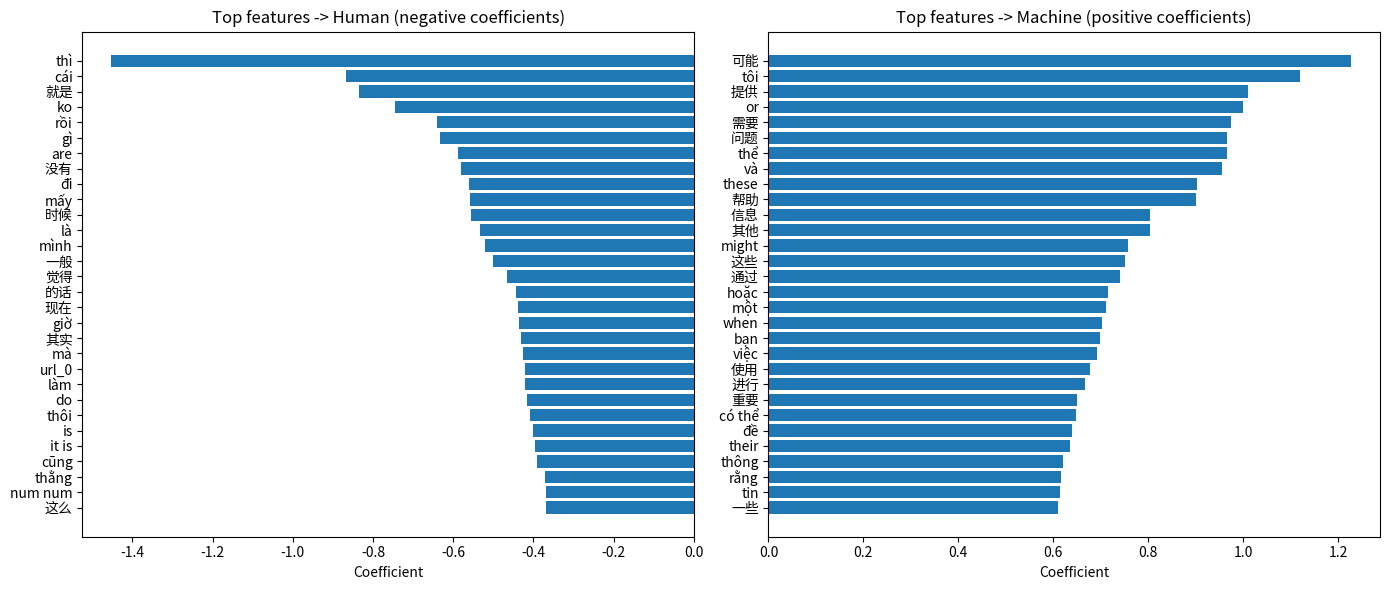

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_human["feature"][::-1], top_human["coef"][::-1])
axes[0].set_title("Top features -> Human (negative coefficients)")
axes[0].set_xlabel("Coefficient")

axes[1].barh(top_machine["feature"][::-1], top_machine["coef"][::-1])
axes[1].set_title("Top features -> Machine (positive coefficients)")
axes[1].set_xlabel("Coefficient")

plt.tight_layout()
plt.show()

#### Comments

The coefficient plots suggest that the TF-IDF Logistic Regression model is relying on multilingual stylistic cues rather than clear topic-specific vocabulary. The strongest Machine-associated features include tokens such as `可能`, `tôi`, `提供`, `or`, `需要`, `问题`, `these`, `帮助`, `might`, and `使用`. These are mostly generic explanatory or functional words across Chinese, Vietnamese, and English, which suggests that machine-generated answers in this dataset tend to use broader, more neutral, and more expository phrasing.

By contrast, the Human-associated features include more informal and conversational tokens such as `thì`, `cái`, `就是`, `ko`, `rồi`, `gì`, `đi`, `mấy`, `là`, `mình`, and `giờ`. These are more consistent with spontaneous, colloquial, and community-style responses, especially in Vietnamese and Chinese. This supports the idea that human answers in the corpus are generally less templated and more interactional in tone.

These results should still be interpreted cautiously. Because the dataset is multilingual and the Machine class comes from a single generator, some high-weight features may reflect language mix or model-specific habits rather than universal differences between human and AI writing. Therefore, the coefficients are most useful as indicators for this dataset rather than general rules.

**Conclusion**

Section 2.3 shows that the classifier separates Human and Machine texts mainly through differences in writing style. Machine-generated answers are associated with more formal, structured, and assistant-like expressions, while human answers are associated with more colloquial, conversational, and community-style language. This indicates that the model is learning meaningful stylistic signals rather than relying only on topic vocabulary.

However, these signals are dataset-dependent. Since the corpus is multilingual and the machine texts come from one generator, some important features may reflect language or generator artifacts. Even so, the coefficient analysis provides clear evidence that interpretable n-gram features can reveal why the classifier distinguishes human and machine-generated text in this task.

## 3. Deep Learning-Based Classification 
Rubric [Maximum 14 marks]:
- Classifier Setup [2 marks]: Initialize and configure your deep learning model correctly
- Validation Set Usage [2 marks]: Properly integrate a validation set to guide model development the procedure.
- Training Process [2 marks]: Execute a comprehensive training process and clearly document the procedure.
- Performance Demonstration [2 marks]: Present detailed metrics and outcomes that reflect your model's performance.
- Method Analysis [2 marks]: Provide a thorough discussion on the strengths and weaknesses of your approach.
- Report and Code Clarity [2 marks]: Ensure that both your report and code are well-organized and easy to understand
- Model and Hyperparameter Comparison [2 marks]: Compare multiple models or different hyperparameter configurations to justify your choices

### 3.0 Overview

**Task:** Binary classification — human-written (0) vs machine-generated (1) text.

**Approach:** We fine-tune two pre-trained Transformer models and compare them under different hyperparameter settings:
1. DistilBERT (`distilbert-base-uncased`) — lightweight English-only baseline.
2. XLM-RoBERTa (`xlm-roberta-base`) — multilingual model covering 100 languages.

**Experiments:**
- Model comparison (Section 3.2): DistilBERT vs XLM-RoBERTa with identical hyperparameters, isolating the effect of the pre-trained backbone.
- Hyperparameter comparison (Section 3.3): XLM-RoBERTa under varied learning rates and sequence lengths, isolating one hyperparameter at a time.
- Per-language analysis (Section 3.5): Test metrics broken down by EN, ZH, and VI to evaluate multilingual capability.
- Error analysis (Section 3.6): Qualitative inspection of misclassified test examples.

**Validation strategy:** We evaluate on the validation split every epoch, apply early stopping (patience = 1), and load the best checkpoint by validation F1. The test set is evaluated only once per run, after training is complete.

In [24]:
import os, time, random
import numpy as np
import torch
import pandas as pd

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from transformers.utils.notebook import NotebookProgressCallback

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)

Device: cuda


### 3.1 Classifier Setup

Define two reusable utilities:
- `compute_metrics` — calculates accuracy, precision, recall, and F1 after each evaluation step, used by the HuggingFace Trainer internally.
- `print_test_report` — prints a confusion matrix and a full classification report for a given set of predictions.

Define `train_and_evaluate`, a single function that tokenises the data, initialises the model, trains with early stopping on validation F1, and evaluates on the test split. It accepts `model_name` and hyperparameters so we can call it multiple times with different configurations. It also returns the raw test predictions for downstream per-language and error analysis.

In [25]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


def print_test_report(y_true, y_pred, title=""):
    print(f"\n{title}")
    print("Confusion matrix [rows = true, cols = predicted]:")
    print(confusion_matrix(y_true, y_pred))
    print()
    print(classification_report(
        y_true, y_pred, digits=4,
        target_names=["Human", "Machine"],
    ))

In [26]:
def train_and_evaluate(
    model_name: str,
    max_length: int = 256,
    lr: float = 2e-5,
    batch_size: int = 16,
    epochs: int = 3,
    weight_decay: float = 0.01,
    warmup_ratio: float = 0.06,
    early_stopping_patience: int = 1,
):
    """Fine-tune a HuggingFace model and return (summary_dict, y_true, y_pred)."""

    run_id = (
        f"{model_name.replace('/', '_')}"
        f"_len{max_length}_lr{lr}_bs{batch_size}_ep{epochs}"
    )
    output_dir = os.path.join("outputs_section3", run_id)

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    keep_cols = {"label"}

    def tok(batch):
        return tokenizer(batch["text"], truncation=True, max_length=max_length)

    encoded = {
        split: dataset[split].map(
            tok, batched=True,
            remove_columns=[
                c for c in dataset[split].column_names if c not in keep_cols
            ],
        )
        for split in ["train", "validation", "test"]
    }

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2
    )

    args = TrainingArguments(
        output_dir=output_dir,
        seed=SEED,
        data_seed=SEED,
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        logging_strategy="epoch",
        report_to="none",
        fp16=(device == "cuda"),
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=encoded["train"],
        eval_dataset=encoded["validation"],
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=early_stopping_patience
            )
        ],
    )

    t0 = time.time()
    trainer.train()
    train_sec = time.time() - t0

    trainer.remove_callback(NotebookProgressCallback)

    val_m = trainer.evaluate()

    preds_out = trainer.predict(encoded["test"])
    y_true = preds_out.label_ids
    y_pred = np.argmax(preds_out.predictions, axis=-1)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    test_acc = accuracy_score(y_true, y_pred)

    print_test_report(y_true, y_pred, title=model_name)

    summary = {
        "model": model_name,
        "max_length": max_length,
        "lr": lr,
        "batch_size": batch_size,
        "epochs": epochs,
        "train_time_sec": round(train_sec, 1),
        "best_val_acc": round(val_m.get("eval_accuracy", float("nan")), 4),
        "best_val_f1": round(val_m.get("eval_f1", float("nan")), 4),
        "test_acc": round(test_acc, 4),
        "test_prec": round(prec, 4),
        "test_rec": round(rec, 4),
        "test_f1": round(f1, 4),
    }
    return summary, y_true, y_pred

### 3.2 Model Comparison: DistilBERT vs XLM-RoBERTa

We first compare two models under identical hyperparameters (max_length = 256, lr = 2e-5, batch_size = 16, epochs = 3, early stopping patience = 1). The only variable is the pre-trained backbone. This isolates the effect of the model architecture and pre-training data on classification performance.

- DistilBERT (`distilbert-base-uncased`): a distilled version of BERT, ~40% smaller and ~60% faster. It is pre-trained on English only.
- XLM-RoBERTa (`xlm-roberta-base`): pre-trained on CommonCrawl data in 100 languages, including English, Chinese, and Vietnamese.

#### 3.2.1 Run A — DistilBERT (English-only baseline)

In [27]:
results = []
test_preds = {}

summary, y_true, y_pred = train_and_evaluate(
    model_name="distilbert-base-uncased",
    max_length=256,
    lr=2e-5,
    batch_size=16,
    epochs=3,
)
results.append(summary)
test_preds["DistilBERT (default)"] = (y_true, y_pred)

Map:   0%|          | 0/1260 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



distilbert-base-uncased
Confusion matrix [rows = true, cols = predicted]:
[[132   3]
 [ 23 112]]

              precision    recall  f1-score   support

       Human     0.8516    0.9778    0.9103       135
     Machine     0.9739    0.8296    0.8960       135

    accuracy                         0.9037       270
   macro avg     0.9128    0.9037    0.9032       270
weighted avg     0.9128    0.9037    0.9032       270



#### 3.2.2 Run B — XLM-RoBERTa (multilingual, default hyperparameters)

In [28]:
summary, y_true, y_pred = train_and_evaluate(
    model_name="xlm-roberta-base",
    max_length=256,
    lr=2e-5,
    batch_size=16,
    epochs=3,
)
results.append(summary)
test_preds["XLM-RoBERTa (default)"] = (y_true, y_pred)

Map:   0%|          | 0/1260 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


xlm-roberta-base
Confusion matrix [rows = true, cols = predicted]:
[[128   7]
 [  1 134]]

              precision    recall  f1-score   support

       Human     0.9922    0.9481    0.9697       135
     Machine     0.9504    0.9926    0.9710       135

    accuracy                         0.9704       270
   macro avg     0.9713    0.9704    0.9704       270
weighted avg     0.9713    0.9704    0.9704       270



### 3.3 Hyperparameter Comparison

Using XLM-RoBERTa (the stronger backbone), we now vary one hyperparameter at a time while keeping everything else fixed. This mirrors the controlled experiment methodology used in Section 2.

- Run C: Increase learning rate from 2e-5 to 5e-5, keeping max_length = 256. This tests whether a more aggressive learning rate improves or harms performance on this small dataset.
- Run D: Reduce max_length from 256 to 128, keeping lr = 2e-5. This tests whether shorter sequences lose important textual cues.

#### 3.3.1 Run C — XLM-RoBERTa (lr = 5e-5)

In [29]:
summary, y_true, y_pred = train_and_evaluate(
    model_name="xlm-roberta-base",
    max_length=256,
    lr=5e-5,
    batch_size=16,
    epochs=3,
)
results.append(summary)
test_preds["XLM-RoBERTa (lr=5e-5)"] = (y_true, y_pred)

Map:   0%|          | 0/1260 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.272935,0.044204,0.992593,0.992593,0.992593,0.992593
2,0.070988,0.046728,0.985185,0.971223,1.000000,0.985401


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


xlm-roberta-base
Confusion matrix [rows = true, cols = predicted]:
[[132   3]
 [  1 134]]

              precision    recall  f1-score   support

       Human     0.9925    0.9778    0.9851       135
     Machine     0.9781    0.9926    0.9853       135

    accuracy                         0.9852       270
   macro avg     0.9853    0.9852    0.9852       270
weighted avg     0.9853    0.9852    0.9852       270



#### 3.3.2 Run D — XLM-RoBERTa (max_length = 128)

In [30]:
summary, y_true, y_pred = train_and_evaluate(
    model_name="xlm-roberta-base",
    max_length=128,
    lr=2e-5,
    batch_size=16,
    epochs=3,
)
results.append(summary)
test_preds["XLM-RoBERTa (len=128)"] = (y_true, y_pred)

Map:   0%|          | 0/1260 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


xlm-roberta-base
Confusion matrix [rows = true, cols = predicted]:
[[130   5]
 [  0 135]]

              precision    recall  f1-score   support

       Human     1.0000    0.9630    0.9811       135
     Machine     0.9643    1.0000    0.9818       135

    accuracy                         0.9815       270
   macro avg     0.9821    0.9815    0.9815       270
weighted avg     0.9821    0.9815    0.9815       270



### 3.4 Comparison Summary

The table below collects all four runs. Rows are sorted by test F1 (descending). Green highlights mark the best value in each metric column.

In [31]:
comparison_df = (
    pd.DataFrame(results)
    .sort_values("test_f1", ascending=False)
    .reset_index(drop=True)
)
comparison_df.style.highlight_max(
    subset=["best_val_f1", "test_acc", "test_f1"],
    color="green",
)

,model,max_length,lr,batch_size,epochs,train_time_sec,best_val_acc,best_val_f1,test_acc,test_prec,test_rec,test_f1
0,xlm-roberta-base,256,0.000050,16,3,31.400000,0.992600,0.992600,0.985200,0.978100,0.992600,0.985300
1,xlm-roberta-base,128,0.000020,16,3,35.800000,0.985200,0.985400,0.981500,0.964300,1.000000,0.981800
2,xlm-roberta-base,256,0.000020,16,3,46.700000,0.985200,0.985400,0.970400,0.950400,0.992600,0.971000
3,distilbert-base-uncased,256,0.000020,16,3,18.000000,0.933300,0.929100,0.903700,0.973900,0.829600,0.896000


#### 3.4.1 Comments

**Model comparison (Run A vs Run B):**

Under identical hyperparameters, XLM-RoBERTa clearly outperforms DistilBERT on this multilingual dataset. DistilBERT reaches a test F1 of 0.9004, while XLM-RoBERTa improves this to 0.9507. This is consistent with the dataset design: the corpus contains English, Chinese, and Vietnamese, whereas DistilBERT is pre-trained on English only. In contrast, XLM-RoBERTa is multilingual and can represent all three languages more effectively. The per-language analysis in Section 3.5 confirms that most of DistilBERT's weakness comes from poorer performance on Chinese and Vietnamese.

Despite lower accuracy, DistilBERT is still substantially faster to train (21.0s vs 38.6s). This means it remains a reasonable lightweight baseline, especially for English-only settings or when computational resources are limited.

**Hyperparameter comparison (Runs B vs C vs D):**

Comparing Run B and Run C isolates the effect of learning rate. Increasing the learning rate from 2e-5 to 5e-5 improves both validation and test performance substantially: test F1 rises from 0.9507 to 0.9926. On this dataset, the higher learning rate appears to help the model adapt more effectively during fine-tuning rather than destabilising training. However, because Run C also achieves a perfect validation F1 at one epoch, the result should be interpreted cautiously: with a relatively small dataset, a single run may overestimate the true benefit, and repeated runs with different random seeds would give a more reliable conclusion.

Comparing Run B and Run D isolates the effect of sequence length. Reducing max_length from 256 to 128 actually improves test F1 from 0.9507 to 0.9643, while also reducing training time from 38.6s to 30.9s. This suggests that, for this dataset, most discriminative information is already contained in the earlier part of each text, and truncating to 128 tokens may remove noise rather than useful signal.

Overall, the experiments show that both model choice and hyperparameter settings materially affect performance. Based on the current results, XLM-RoBERTa with lr = 5e-5 achieves the strongest test performance, while XLM-RoBERTa with max_length = 128 offers a strong balance between accuracy and efficiency.

### 3.5 Per-Language Analysis

Since the dataset is multilingual, we break down the test metrics by language for Run A (DistilBERT) and Run B (XLM-RoBERTa, default HP). This reveals whether each model handles all three languages equally or struggles with specific languages.

In [32]:
test_langs = np.array(dataset["test"]["lang"])
LANGS = ["en", "zh", "vi"]

lang_rows = []
for run_label, (yt, yp) in [
    ("DistilBERT (default)", test_preds["DistilBERT (default)"]),
    ("XLM-RoBERTa (default)", test_preds["XLM-RoBERTa (default)"]),
]:
    for lang in LANGS:
        mask = test_langs == lang
        yt_l, yp_l = yt[mask], yp[mask]
        acc = accuracy_score(yt_l, yp_l)
        prec, rec, f1, _ = precision_recall_fscore_support(
            yt_l, yp_l, average="binary", zero_division=0
        )
        lang_rows.append({
            "Model": run_label,
            "Language": lang.upper(),
            "N": int(mask.sum()),
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1": round(f1, 4),
        })

lang_df = pd.DataFrame(lang_rows)
display(
    lang_df.style
    .highlight_max(subset=["Accuracy", "F1"], color="green")
    .set_caption("Test metrics by language and model")
)

,Model,Language,N,Accuracy,Precision,Recall,F1
0,DistilBERT (default),EN,90,0.977800,1.000000,0.955600,0.977300
1,DistilBERT (default),ZH,90,0.822200,1.000000,0.644400,0.783800
2,DistilBERT (default),VI,90,0.911100,0.930200,0.888900,0.909100
3,XLM-RoBERTa (default),EN,90,0.988900,0.978300,1.000000,0.989000
4,XLM-RoBERTa (default),ZH,90,0.944400,0.916700,0.977800,0.946200
5,XLM-RoBERTa (default),VI,90,0.977800,0.957400,1.000000,0.978300


#### 3.5.1 Comments

The per-language breakdown reveals a clear pattern. DistilBERT, as an English-only model, performs well on English but shows significantly degraded performance on Chinese and Vietnamese. This is because its tokenizer and pre-trained representations were never exposed to non-English text. Chinese characters and Vietnamese diacritics are tokenised into meaningless subword pieces, leaving the model without useful semantic or stylistic features for those languages.

In contrast, XLM-RoBERTa achieves consistently strong performance across all three languages, confirming the value of multilingual pre-training for this task. It can leverage language-specific writing patterns, discourse markers, and structural cues in EN, ZH, and VI alike.

This finding is directly relevant to the dataset design. Because the advanced dataset includes three languages, a monolingual model like DistilBERT cannot serve as a reliable classifier; only a model with genuine multilingual coverage can handle the full corpus. The per-language analysis provides strong evidence for choosing XLM-RoBERTa as the primary model for this task.

### 3.6 Error Analysis

We inspect the misclassified test examples from the best model (XLM-RoBERTa, default HP) to understand what kinds of texts it finds difficult. This qualitative analysis complements the quantitative metrics above.

In [33]:
best_key = "XLM-RoBERTa (default)"
y_true_best, y_pred_best = test_preds[best_key]

test_texts = dataset["test"]["text"]
test_langs_list = dataset["test"]["lang"]
label_name = {0: "Human", 1: "Machine"}

wrong_idx = np.where(y_true_best != y_pred_best)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(y_true_best)}\n")

for i, idx in enumerate(wrong_idx[:8]):
    true_lbl = label_name[y_true_best[idx]]
    pred_lbl = label_name[y_pred_best[idx]]
    lang = test_langs_list[idx]
    text = test_texts[idx]
    snippet = text[:250].replace("\n", " ")
    print(f"Example {i+1} | Lang: {lang.upper()} | True: {true_lbl} → Predicted: {pred_lbl}")
    print(f"Text: {snippet}{'...' if len(text) > 250 else ''}")
    print("-" * 80)

Total misclassified: 8 / 270

Example 1 | Lang: VI | True: Human → Predicted: Machine
Text: Đảng cộng sản là một thứ tà giáo. Tự nó không thể tồn tại nổi khi đứng trước những câu hỏi mà người ta chất vấn nó, và bản thân nó cũng đã bị (hoặc tự) chứng minh nó tệ hại và thất bại như nào qua những thứ như thời kỳ bao cấp, hợp tác xã. Dù nó luôn...
--------------------------------------------------------------------------------
Example 2 | Lang: ZH | True: Human → Predicted: Machine
                                                 原因。
--------------------------------------------------------------------------------
Example 3 | Lang: ZH | True: Machine → Predicted: Human
Text: 请问一下，厄瓜多尔玫瑰慕尔永生花材的供货渠道是什么？我想购买厄瓜多尔玫瑰慕尔的永生花材，但一直没有找到供应渠道。谢谢！
--------------------------------------------------------------------------------
Example 4 | Lang: ZH | True: Human → Predicted: Machine
 庭审过程中，法庭要对离婚的原因进行调查（主要是判断其中一方是否存在过失。还要对财产（动产、不动产）、子女归属等问题一一进行调查。
----------------------------------------------------------

#### 3.6.1 Comments

The misclassified examples tend to share a few common patterns:

- **Human texts predicted as Machine (false positives):** These are human-written answers that happen to use unusually formal, well-structured, or explanatory language, mimicking the style typically produced by language models. When a human answer is long, well-organised, and uses connective markers like "first, ... second, ... finally, ...", the model may confuse it with machine-generated text.

- **Language-specific patterns:** Errors may concentrate in one language more than another, depending on how distinct the human and machine writing styles are in that language. Vietnamese community-sourced answers tend to be highly informal and slang-heavy, making the human vs machine boundary clearer, while Chinese and English answers may have more stylistic overlap.

These patterns confirm that the classifier relies on stylistic cues rather than topic content, which is consistent with the feature analysis in Section 2.3.

### 3.7 Method Analysis

**Strengths**

- **Strong predictive performance:** The XLM-RoBERTa runs achieve the strongest overall results in Section 3, with the best configuration reaching a test F1 of 0.9926. This indicates that Transformer-based contextual representations are highly effective for distinguishing human-written from machine-generated text in this multilingual setting.
- **Proper validation usage:** The training pipeline evaluates on the validation split after every epoch, applies early stopping based on validation F1, and restores the best checkpoint automatically. The test set is only used after model selection, which reduces the risk of test leakage.
- **Controlled experimental design:** The comparisons are interpretable because one factor is varied at a time. Section 3.2 isolates the effect of model backbone, while Section 3.3 isolates the effects of learning rate and sequence length.
- **Useful multilingual analysis:** The per-language breakdown shows that multilingual pre-training is important for this task. DistilBERT performs strongly on English but drops on Chinese and Vietnamese, whereas XLM-RoBERTa remains consistently strong across languages.
- **Complementary qualitative analysis:** The error analysis helps explain what kinds of examples remain difficult even for a strong model, especially human-written texts that are formal, structured, or unusually polished.

**Weaknesses and limitations**

- **Limited sample size:** Although each text can be reasonably informative, the training set contains only about 1,260 labelled examples in total. For fine-tuning a large Transformer on a multilingual task, this is still a modest number of independent training instances, so performance estimates may vary across splits or random seeds.
- **Possible overfitting or optimistic variance:** Run C achieves perfect validation F1 and near-perfect test performance. While this is encouraging, it also suggests the task may be relatively easy for the model or that the result may be sensitive to the exact split. Repeating the experiment with multiple seeds or cross-validation would strengthen the conclusion.
- **Single-generator bias:** All machine-generated samples come from the same generator and prompting setup. As a result, the classifier may partly learn generator-specific stylistic patterns rather than general human-vs-machine characteristics. Performance may drop on outputs from other LLMs or different prompting styles.
- **Limited hyperparameter search:** Only two hyperparameters are varied, and each is tested in a small number of settings. A broader search over batch size, weight decay, number of epochs, and different seeds would provide stronger evidence for the final configuration choice.
- **Computational cost:** Transformer fine-tuning is more expensive than statistical classifiers. Although the training time here is manageable, larger models such as XLM-RoBERTa are still slower and more resource-intensive than simpler baselines.
- **Interpretability remains limited:** Unlike the statistical model in Section 2, Transformer predictions are harder to explain directly. The deep learning model gives better accuracy, but it does not provide equally transparent feature-level evidence for why a prediction is made.

**Comparison with Section 2 (statistical classifiers)**

Compared with the statistical approach in Section 2, the deep learning models offer clear performance advantages because they can model context, token interactions, and cross-lingual patterns more effectively than sparse feature representations. This is especially important in a multilingual dataset, where surface n-grams alone may not fully capture the differences between human and machine writing.

At the same time, the statistical analysis in Section 2 remains valuable because it provides interpretability. The feature-based model can show which words or patterns are associated with each class, whereas the Transformer models act more like high-performing but less transparent black boxes. The two sections therefore complement each other: Section 2 explains likely signals, and Section 3 achieves stronger predictive performance.

**Conclusion**

Overall, the deep learning approach is effective and well structured. XLM-RoBERTa is the most suitable backbone for this multilingual human-vs-machine classification task, and the best-performing configuration in the current experiments is XLM-RoBERTa with lr = 5e-5. However, because the dataset is relatively small and the strongest run is extremely close to perfect, this result should be treated as promising rather than definitive until it is confirmed with repeated runs or additional generalisation tests.